In [1]:
import pandas as pd 
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import numpy as np

In [3]:
base = os.path.join(os.getcwd(),'..','data')

In [4]:
weather = os.path.join(base,'weather')
pdsi = os.path.join(base,'pdsi')

In [5]:
gr_plot = os.path.join(base,'plots')
os.makedirs(gr_plot,exist_ok=True)

In [6]:
major_corn = ['IOWA']

In [7]:
def get_weather(fn,y,m):
    df=pd.read_csv(fn)
    df[['temperature_2m_min', 'temperature_2m_max', 'temperature_2m']] = df[['temperature_2m_min', 'temperature_2m_max', 'temperature_2m']]-273.15
    df[['total_precipitation_sum']]=df[['total_precipitation_sum']]*1000
    df.drop(columns=['system:index', 'FID', 'State_Code','Program', 'Flowing_St', 'FID_1'],inplace=True)
    params = ['temperature_2m_min', 'temperature_2m_max', 'temperature_2m', 'total_precipitation_sum']
    rename_dict = {'temperature_2m_min':'Tmin', 'temperature_2m_max':'Tmax', 'temperature_2m':'Tmean', 'total_precipitation_sum':'Precipitation'}
    df[params] = df[params].round(2)
    df['Year']=y
    df['Month']=m
    # df = df[df['Month'].isin(range(4,10))]
    df.rename(columns=rename_dict,inplace=True)
    return df

In [8]:
def get_pdsi(fn):
    df = pd.read_csv(fn)
    df.drop(columns=['system:index', 'FID', 'State_Code', 'Program','Flowing_St', 'FID_1'],inplace=True)
    df= df.set_index('State_Name')
    df = df.T
    df_final = pd.DataFrame()
    for f in df.columns:
        temp = df[[f]]*0.01
        temp.rename(columns={f:'pdsi'},inplace=True)
        temp['State'] = f
        temp['Date']=temp.index
        temp['Date'] = pd.to_datetime(temp['Date'],format='%Y%m_pdsi')
        temp['Month'] = temp['Date'].apply(lambda x:x.month)
        temp['Year'] = temp['Date'].apply(lambda x:x.year)
        # temp = temp[temp['Month'].isin(range(4,11))]
        df_final=pd.concat([df_final,temp])
    return df_final

In [9]:
df_weather = pd.DataFrame()
for y in range(2010,2020):
    for m in range(1,13):
        fn = os.path.join(weather,'USA_ERA5_'+str(y)+'-'+str(m)+'.csv')
        df_weather = pd.concat([df_weather,get_weather(fn,y,m)])

In [10]:
def define_drought(val):
    cond= np.nan
    if val>=4.0:
        cond = 'Extremely wet'
    elif val<4.0 and val >=3:
        cond = 'Very wet'
    elif val<3.0 and val >=2:
        cond = 'Moderate wet'
    elif val<2.0 and val >=1:
        cond = 'Slightly wet'
    elif val<1 and val >=0.5:
        cond = 'Incipient wet spell'
    elif val<0.5 and val >=-0.5:
        cond = 'Near normal'
    elif val<-0.5 and val >=-1:
        cond = 'Incipient dry spell'
    elif val<-1 and val >=-2:
        cond = 'Mild drought'
    elif val<-2 and val >=-3:
        cond = 'Moderate drought'
    elif val<-3 and val >=-4:
        cond = 'Severe drought'
    elif val<-4:
        cond = 'Extreme drought'
    return cond

In [11]:
df_pdsi = pd.DataFrame()
for y in range(2010,2020):
    fn = os.path.join(pdsi,'PDSI_'+str(y)+'.csv')
    df_pdsi = pd.concat([df_pdsi,get_pdsi(fn)])

In [12]:
df_pdsi['Condition'] = df_pdsi['pdsi'].map(define_drought) 

In [13]:
df_pdsi.to_excel(os.path.join(base,'..','compiled values','PDSI_compiled.xlsx'))

In [14]:
df_pdsi.head()

State_Name,pdsi,State,Date,Month,Year,Condition
201001_pdsi,3.835106,ALABAMA,2010-01-01,1,2010,Very wet
201002_pdsi,3.252447,ALABAMA,2010-02-01,2,2010,Very wet
201003_pdsi,2.781349,ALABAMA,2010-03-01,3,2010,Moderate wet
201004_pdsi,1.791046,ALABAMA,2010-04-01,4,2010,Slightly wet
201005_pdsi,2.386150,ALABAMA,2010-05-01,5,2010,Moderate wet


In [15]:
temp = df_pdsi.drop(columns=['Condition'])
temp = temp[temp['Month'].isin(range(4,11))]
temp = temp.groupby(['State','Year']).mean()
temp = temp.reset_index()
temp.drop(columns=['Date','Month'],inplace=True)
temp['Condition']=temp['pdsi'].map(define_drought)
temp.to_excel(os.path.join(base,'..','compiled values','PDSI_compiled_yearly.xlsx'))

In [23]:
df_dr = df_pdsi.copy()
drought = df_dr[(df_dr['Month']>3) & (df_dr['Month']<11)].drop(columns=['State','Condition','Date']).groupby('Year').mean().reset_index()

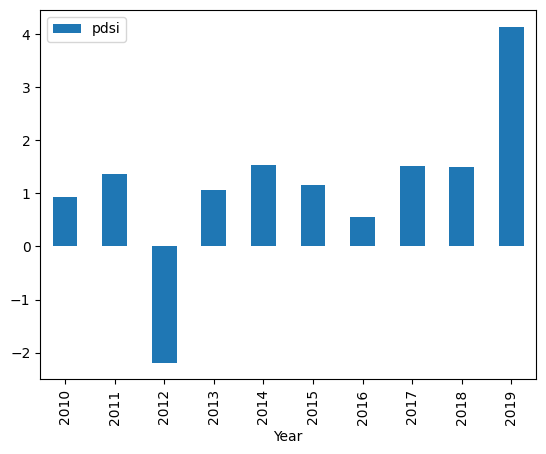

In [24]:
ax = drought.plot(x='Year',y='pdsi',kind='bar')
fn = os.path.join(gr_plot,'PDSI.png')
fig = ax.get_figure()
# fig.savefig(fn)

In [30]:
df_clim = df_weather.copy()

In [31]:
df_clim_temp = df_clim[['Tmin', 'Tmax', 'Tmean','State_Name', 'Year','Month' ]]
df_clim_rf = df_clim[['Precipitation','State_Name', 'Year','Month' ]]

In [32]:
grp_t = df_clim_temp.drop(columns=['State_Name','Month']).groupby('Year').mean()
grp_r = df_clim_rf.groupby(['State_Name','Year']).mean().reset_index().drop(columns=['State_Name','Month']).groupby('Year').sum()

In [33]:
grp_r2 = df_clim_rf.drop(columns=['State_Name']).groupby(['Year','Month']).sum()

In [34]:
grp_r2=grp_r2.reset_index()

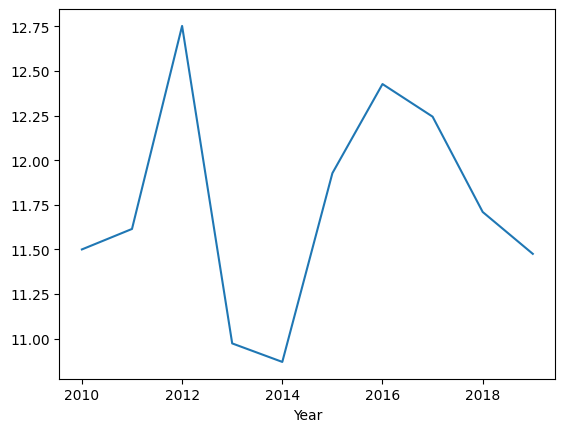

In [35]:
ax = grp_t['Tmean'].plot()
fn = os.path.join(gr_plot,'Temp.png')
fig = ax.get_figure()
# fig.savefig(fn)

In [36]:
grp_r2['Date'] = pd.to_datetime(grp_r2['Year'].astype(str)+'-'+grp_r2['Month'].astype(str),format='%Y-%m')

In [37]:
ci = 1.96*grp_r2['Precipitation'].std()/np.sqrt(grp_r2.shape[0])
grp_r2['ul']= grp_r2['Precipitation']+ci
grp_r2['ll']= grp_r2['Precipitation']-ci

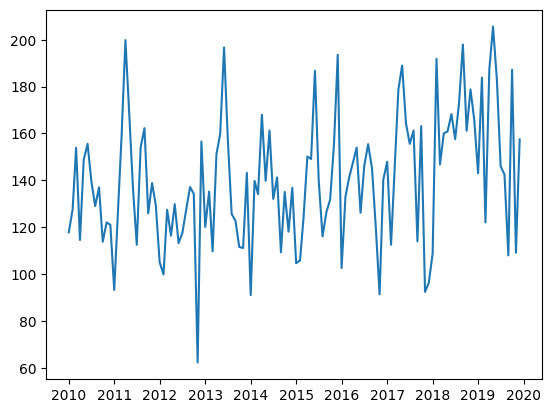

In [38]:
# sns.regplot(data=grp_r2,x='Date',y='Precipitation')
fig, ax = plt.subplots()
x = grp_r2['Date']
ax.plot(x, grp_r2['Precipitation'])

fn = os.path.join(gr_plot,'RF.png')
fig = ax.get_figure()
# fig.savefig(fn)